# Baseline Behavior Sweep

One dated investigation notebook in a repeatable series -- see `notebooks/README.md` for the index and workflow. Never edited in place once committed.

**Purpose.** Establish an empirical baseline for the kernel commit recorded below: what behavior does it produce, and how complex is the relationship between configuration and outcome?

**Non-goals.** This notebook does not redesign the kernel, implement newly-discovered behavior, or modify telemetry.

In [1]:
from __future__ import annotations

import copy

import matplotlib.pyplot as plt
import pandas as pd

from simlab._merge import deep_merge
from sweep_utils import (
    between_scenario_variance_share,
    dedupe_scenarios,
    expand_ofat_scenarios,
    plot_parameter_response,
    plot_predictability,
    plot_variance_shares,
    predictability_probe,
    reproducibility_header,
    run_sweep,
)

%matplotlib inline
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100

## Reproducibility header

Checkpoint for which kernel version produced the results below. **Rule:** only commit this notebook once `kernel_commit_on_main` prints `True` (see `notebooks/README.md` for why).

In [2]:
header = reproducibility_header("2026-08-08-baseline-behavior-sweep")

Notebook reproducibility header
  experiment_name      : 2026-08-08-baseline-behavior-sweep
  executed_at_utc      : 2026-08-09T02:22:10.358475+00:00
  git_branch           : notebook/baseline-behavior-sweep
  git_commit           : 9c056cf2c14b961984711786e02a8aa0c70747ba
  git_dirty            : True
  kernel_commit        : 9c056cf2c14b961984711786e02a8aa0c70747ba
  kernel_path_clean    : True
  kernel_commit_on_main: False
  schema_version       : 0.1.0

notebook to notebooks/ until the kernel code it exercised
has actually merged to main -- rerun this cell after that merge to
confirm a stable, permanent commit reference.


## Sweep design

**Baseline.** 60 agents, one claim, moderate observation/noise (`configs/default.yaml`'s spirit): unbounded social acceptance, static trust, verification the strongest channel. **Axes.** `confidence_bound`, `trust_update_rate`, `default_trust`, `hear_weight` (social mechanisms) and `private_event_rate`, `attention`, `noise_regime`, `verify_cost` (channel strength) -- chosen to separate "does the social machinery matter" from "does the truth-seeking machinery matter." This notebook also adds an interaction grid (`confidence_bound x trust_update_rate`; 5 of its 9 points coincide exactly with baseline/OFAT scenarios above, so only the 4 new combinations are actually re-run), structural scenarios (population size, profile composition), and a `social_only` boundary condition (observation disabled, `VERIFY` scored to never win) that isolates social dynamics from any truth-grounded channel -- see those sections below.

Axes are one-factor-at-a-time (OFAT) from a single baseline to stay interpretable; a full grid is reserved for a parameter pair with a clear a-priori interaction hypothesis. Each scenario runs `len(SEEDS)` replicates so scenario effects can be separated from stochastic ones.

In [3]:
STEPS = 300
SEEDS = list(range(10))

BASELINE_CFG = {
    "world": {
        "rng_seed": 0,
        "truths": {0: True},
        "noise": {"OBSERVE": 0.1, "HEAR": 0.15, "VERIFY": 0.05},
        "observation": {"private_event_rate": 0.1, "global_event_rate": 0.0},
    },
    "agent": {
        "defaults": {
            "observation": {"attention": 1.0, "bias": 0.0},
            "trust": {"default": 0.5},
            "social": {
                "confidence_bound": 1.0,
                "trust_update_rate": 0.0,
                "update_trust_on_rejection": True,
            },
            "learning": {
                "rate": 0.1,
                "observe_weight": 0.6,
                "hear_weight": 0.3,
                "verify_weight": 1.0,
            },
            "action_preference": {
                "IDLE": 0.0,
                "VERIFY": 0.9,
                "COMMUNICATE": 0.7,
                "BROADCAST": 0.5,
            },
            "action_cost": {
                "IDLE": 0.0,
                "VERIFY": 0.35,
                "COMMUNICATE": 0.15,
                "BROADCAST": 0.30,
            },
        },
        "profiles": [{"name": "default", "count": 60}],
    },
}

OFAT_AXES: dict[str, list[tuple[str, dict]]] = {
    "confidence_bound": [  # baseline: 1.0 (unbounded acceptance)
        (
            "narrow_0.05",
            {"agent": {"defaults": {"social": {"confidence_bound": 0.05}}}},
        ),
        (
            "moderate_0.3",
            {"agent": {"defaults": {"social": {"confidence_bound": 0.3}}}},
        ),
    ],
    "trust_update_rate": [  # baseline: 0.0 (static trust)
        (
            "moderate_0.2",
            {"agent": {"defaults": {"social": {"trust_update_rate": 0.2}}}},
        ),
        ("fast_0.6", {"agent": {"defaults": {"social": {"trust_update_rate": 0.6}}}}),
    ],
    "default_trust": [  # baseline: 0.5
        ("low_0.1", {"agent": {"defaults": {"trust": {"default": 0.1}}}}),
        ("high_0.9", {"agent": {"defaults": {"trust": {"default": 0.9}}}}),
    ],
    "hear_weight": [  # baseline: 0.3
        ("off_0.0", {"agent": {"defaults": {"learning": {"hear_weight": 0.0}}}}),
        ("dominant_0.8", {"agent": {"defaults": {"learning": {"hear_weight": 0.8}}}}),
    ],
    "private_event_rate": [  # baseline: 0.1
        ("rare_0.02", {"world": {"observation": {"private_event_rate": 0.02}}}),
        ("frequent_0.4", {"world": {"observation": {"private_event_rate": 0.4}}}),
    ],
    "attention": [  # baseline: 1.0
        ("low_0.2", {"agent": {"defaults": {"observation": {"attention": 0.2}}}}),
        ("moderate_0.6", {"agent": {"defaults": {"observation": {"attention": 0.6}}}}),
    ],
    "noise_regime": [  # baseline: OBSERVE=0.1 HEAR=0.15 VERIFY=0.05
        ("none", {"world": {"noise": {"OBSERVE": 0.0, "HEAR": 0.0, "VERIFY": 0.0}}}),
        ("high", {"world": {"noise": {"OBSERVE": 0.3, "HEAR": 0.35, "VERIFY": 0.2}}}),
    ],
    "verify_cost": [  # baseline: 0.35
        ("cheap_0.1", {"agent": {"defaults": {"action_cost": {"VERIFY": 0.1}}}}),
        ("expensive_0.7", {"agent": {"defaults": {"action_cost": {"VERIFY": 0.7}}}}),
    ],
}

# Mirrors configs/heterogeneous.yaml's mix, scaled to the baseline's 60 agents.
HETEROGENEOUS_PROFILES = [
    {"name": "attentive", "count": 24, "observation": {"attention": 0.95}},
    {"name": "distracted", "count": 24, "observation": {"attention": 0.35}},
    {
        "name": "skeptical",
        "count": 12,
        "trust": {"default": 0.25},
        "learning": {"hear_weight": 0.15, "verify_weight": 1.2},
        "action_preference": {"VERIFY": 1.0, "COMMUNICATE": 0.35, "BROADCAST": 0.2},
    },
]

INTERACTION_CONFIDENCE = [0.05, 0.3, 1.0]
INTERACTION_TRUST_RATE = [0.0, 0.2, 0.6]

# Built up under a lowercase name since it's still being assembled; SCENARIOS
# itself is only ever bound once, below, to the final deduplicated result.
scenarios = expand_ofat_scenarios(BASELINE_CFG, OFAT_AXES)

small = deep_merge(
    BASELINE_CFG, {"agent": {"profiles": [{"name": "default", "count": 15}]}}
)
large = deep_merge(
    BASELINE_CFG, {"agent": {"profiles": [{"name": "default", "count": 150}]}}
)
scenarios.append(
    {
        "id": "num_agents:small_15",
        "group": "structural",
        "swept_axis": "num_agents",
        "label": "small_15",
        "cfg": small,
    }
)
scenarios.append(
    {
        "id": "num_agents:large_150",
        "group": "structural",
        "swept_axis": "num_agents",
        "label": "large_150",
        "cfg": large,
    }
)

hetero = copy.deepcopy(BASELINE_CFG)
hetero["agent"]["profiles"] = HETEROGENEOUS_PROFILES
scenarios.append(
    {
        "id": "profile_composition:heterogeneous",
        "group": "structural",
        "swept_axis": "profile_composition",
        "label": "heterogeneous",
        "cfg": hetero,
    }
)

# No truth-grounded evidence at all: observation off, and VERIFY's
# preference set to 0 makes its score (-cost) strictly worse than IDLE
# (score 0), so it's never chosen either. The only memory type ever
# formed is HEAR, sourced from agents' own random initial beliefs --
# this isolates bounded confidence / trust dynamics as a pure opinion-
# dynamics process, uncontaminated by a truth-seeking channel that would
# otherwise dominate the outcome (see the OFAT results below).
social_only_overrides = {
    "world": {"observation": {"private_event_rate": 0.0, "global_event_rate": 0.0}},
    "agent": {"defaults": {"action_preference": {"VERIFY": 0.0}}},
}
for cb, label in [(0.05, "narrow_cb"), (1.0, "wide_cb")]:
    cfg = deep_merge(
        BASELINE_CFG,
        deep_merge(
            social_only_overrides,
            {"agent": {"defaults": {"social": {"confidence_bound": cb}}}},
        ),
    )
    scenarios.append(
        {
            "id": f"social_only:{label}",
            "group": "structural",
            "swept_axis": "social_only",
            "label": label,
            "cfg": cfg,
        }
    )

for cb in INTERACTION_CONFIDENCE:
    for tur in INTERACTION_TRUST_RATE:
        cfg = deep_merge(
            BASELINE_CFG,
            {
                "agent": {
                    "defaults": {
                        "social": {"confidence_bound": cb, "trust_update_rate": tur}
                    }
                }
            },
        )
        scenarios.append(
            {
                "id": f"interaction:cb={cb},tur={tur}",
                "group": "interaction",
                "swept_axis": "confidence_bound_x_trust_update_rate",
                "label": f"cb={cb},tur={tur}",
                "cfg": cfg,
            }
        )

# Several of the 9 (confidence_bound, trust_update_rate) grid points resolve to
# the same config as a baseline/OFAT scenario built above (e.g. cb=1.0, tur=0.0
# is exactly the baseline). dedupe_scenarios finds those by resolved-config
# fingerprint, so a duplicate combination is never re-run and double-counted
# in the aggregates below, without having to work out and list each
# coincidence by hand.
SCENARIOS, INTERACTION_DUPLICATES = dedupe_scenarios(scenarios)

print(
    f"{len(SCENARIOS)} unique scenario configs x {len(SEEDS)} seeds = {len(SCENARIOS) * len(SEEDS)} runs"
)

26 unique scenario configs x 10 seeds = 260 runs


## Executing the sweep

`run_sweep()` executes each scenario x seed combination through `execute_run()` unmodified, keeping full telemetry only for `seed=0` per scenario. Nothing is persisted to `runs/`, keeping the repo clean -- `result.scenario`/`result.summary` already carry what's needed.

In [4]:
%%time

runs, trajectories = run_sweep(SCENARIOS, SEEDS, STEPS)
print(f"Analysis dataset: {runs.shape[0]} runs x {runs.shape[1]} columns")
runs.head()

Analysis dataset: 260 runs x 182 columns
CPU times: user 21.2 s, sys: 50.3 ms, total: 21.3 s
Wall time: 21.4 s


,scenario_id,scenario_group,swept_axis,label,seed,run_id,scenario_fingerprint,run_spec_fingerprint,num_agents,num_claims,private_event_rate,global_event_rate,noise.OBSERVE,noise.HEAR,noise.VERIFY,graph.num_nodes,graph.num_edges,graph.edge_density,graph.mean_out_degree,graph.std_out_degree,graph.min_out_degree,graph.max_out_degree,graph.fraction_isolated,graph.adjacency_fingerprint,profile_count.default,profile_fraction.default,agent_attention_mean,agent_attention_std,agent_bias_mean,agent_bias_std,...,agent_profile.distracted.confidence_bound,agent_profile.distracted.trust_update_rate,agent_profile.distracted.update_trust_on_rejection,agent_profile.distracted.action_preference.IDLE,agent_profile.distracted.action_cost.IDLE,agent_profile.distracted.action_preference.VERIFY,agent_profile.distracted.action_cost.VERIFY,agent_profile.distracted.action_preference.COMMUNICATE,agent_profile.distracted.action_cost.COMMUNICATE,agent_profile.distracted.action_preference.BROADCAST,agent_profile.distracted.action_cost.BROADCAST,agent_profile.skeptical.order_index,agent_profile.skeptical.attention,agent_profile.skeptical.bias,agent_profile.skeptical.learning_rate,agent_profile.skeptical.observe_weight,agent_profile.skeptical.hear_weight,agent_profile.skeptical.verify_weight,agent_profile.skeptical.default_trust,agent_profile.skeptical.confidence_bound,agent_profile.skeptical.trust_update_rate,agent_profile.skeptical.update_trust_on_rejection,agent_profile.skeptical.action_preference.IDLE,agent_profile.skeptical.action_cost.IDLE,agent_profile.skeptical.action_preference.VERIFY,agent_profile.skeptical.action_cost.VERIFY,agent_profile.skeptical.action_preference.COMMUNICATE,agent_profile.skeptical.action_cost.COMMUNICATE,agent_profile.skeptical.action_preference.BROADCAST,agent_profile.skeptical.action_cost.BROADCAST
0,baseline,baseline,NaN,baseline,0,81fdf3cc1d434de1a4b9d057d967f914,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,4b4a97a6655493e39082f8a6d2f9b4946dcc1ce628e0c6...,60,1,0.1,0.0,0.1,0.15,0.05,60,125,0.035311,2.083333,1.508771,0,4,0.183333,1094256658584309360,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baseline,baseline,NaN,baseline,1,120e8f4bf9314d8099b92cabd47d669d,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,67d5c0ac6384a1a1e489fdb2560e1f388c2de59c48ebf2...,60,1,0.1,0.0,0.1,0.15,0.05,60,136,0.038418,2.266667,1.481741,0,4,0.166667,10023458850868456750,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline,baseline,NaN,baseline,2,079eabf5857043fda9c422a40df532fc,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,30d3451319c69c38fa7db3936fd8a5061207f84ea2d92b...,60,1,0.1,0.0,0.1,0.15,0.05,60,107,0.030226,1.783333,1.592604,0,4,0.316667,7592705126979031321,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,baseline,baseline,NaN,baseline,3,b350cfcc86d84c49a593ae21f08dadc1,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,3665632d046cce9be92f067b09d79d0095321fd12a5bc2...,60,1,0.1,0.0,0.1,0.15,0.05,60,138,0.038983,2.300000,1.405940,0,4,0.133333,11803418477097846842,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,baseline,baseline,NaN,baseline,4,4560e458a8af463db5511924fc9edef7,658dbdd57108750d48f9351d370937cdfc7c71fa29e5cd...,20bb391fbea24afd4a978d60af8470b540851a3b0d594e...,60,1,0.1,0.0,0.1,0.15,0.05,60,106,0.029944,1.766667,1.358512,0,4,0.250000,5466998976349032876,60.0,1.0,1.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Outcome diversity

Label rates across all runs. Split into `truth_anchored` (everything except `social_only`) vs. `social_only`, since they turned out to be qualitatively different regimes.

Label rates, truth-anchored scenarios (n=240):
converged                0.904
final_consensus          0.992
final_truth_aligned      1.000
final_false_consensus    0.000

Label rates, social-only scenarios (n=20):
converged                0.0
final_consensus          0.0
final_truth_aligned      0.0
final_false_consensus    0.0


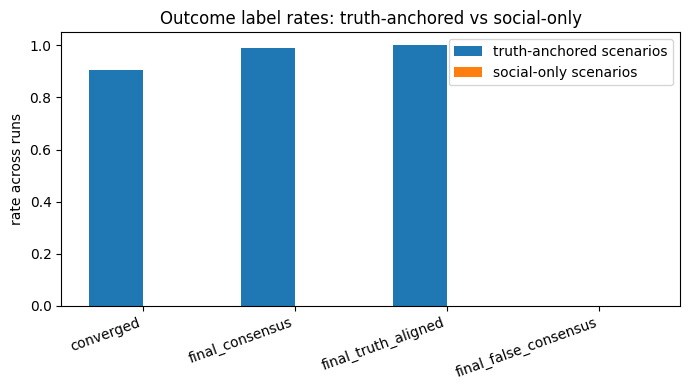

In [5]:
label_cols = [
    "converged",
    "final_consensus",
    "final_truth_aligned",
    "final_false_consensus",
]
truth_anchored = runs[runs.swept_axis != "social_only"]
social_only = runs[runs.swept_axis == "social_only"]

print(f"Label rates, truth-anchored scenarios (n={len(truth_anchored)}):")
print(truth_anchored[label_cols].mean().round(3).to_string())
print(f"\nLabel rates, social-only scenarios (n={len(social_only)}):")
print(social_only[label_cols].mean().round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
x = list(range(len(label_cols)))
width = 0.35
ax.bar(
    [i - width / 2 for i in x],
    truth_anchored[label_cols].mean(),
    width,
    label="truth-anchored scenarios",
)
ax.bar(
    [i + width / 2 for i in x],
    social_only[label_cols].mean(),
    width,
    label="social-only scenarios",
)
ax.set_xticks(x)
ax.set_xticklabels(label_cols, rotation=20, ha="right")
ax.set_ylabel("rate across runs")
ax.set_title("Outcome label rates: truth-anchored vs social-only")
ax.legend()
plt.tight_layout()
plt.show()

**Reading this:** When any truth-grounded channel is present, the kernel produces one regime: `final_truth_aligned=True` in 100% of 240 truth-anchored runs, `final_consensus` in 99.2%, `final_false_consensus` in 0%. Removing the channel entirely (`social_only`) flips all three to 0% -- the only condition here where the population doesn't end up truth-aligned; see Mechanism activation below.

## Scenario signal vs. stochastic noise

For each outcome metric, `SS_between / SS_total` (a one-way ANOVA style decomposition on `scenario_id`) separates between-scenario variance from within-scenario (seed) variance.

  final_mean_truth_error: 0.993
  final_mean_claim_belief_variance: 0.343
  mean_belief_volatility: 0.925
  convergence_tick: 0.600


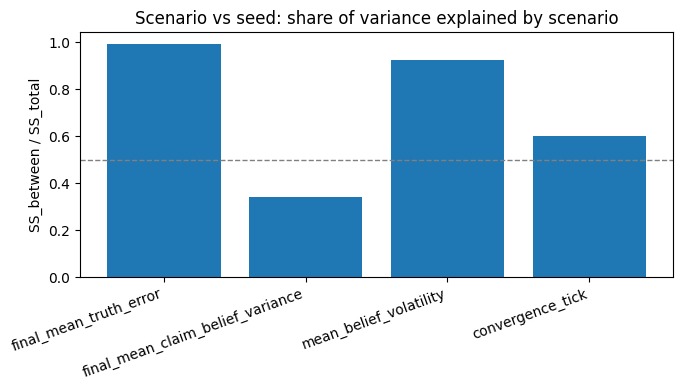

In [6]:
# EDIT: outcome metrics that matter for this investigation.
variance_metrics = [
    "final_mean_truth_error",
    "final_mean_claim_belief_variance",
    "mean_belief_volatility",
    "convergence_tick",
]
variance_shares = {
    m: between_scenario_variance_share(truth_anchored, m) for m in variance_metrics
}
for m, v in variance_shares.items():
    print(f"  {m}: {v:.3f}")

plot_variance_shares(variance_shares)
plt.show()

**Reading this:** `final_mean_truth_error` (99.3%) and `mean_belief_volatility` (92.5%) are almost entirely scenario-driven -- a fixed configuration is highly reproducible across seeds. `convergence_tick` (60.0%) has a real seed-driven component, consistent with it being a threshold-crossing event. `final_mean_claim_belief_variance` (34.3%) is the outlier, but it sits near 0 in almost every scenario, so small absolute fluctuations dominate without being practically meaningful.

## Parameter response

Mean outcome per OFAT axis (baseline + variants), error bars = std across seeds.

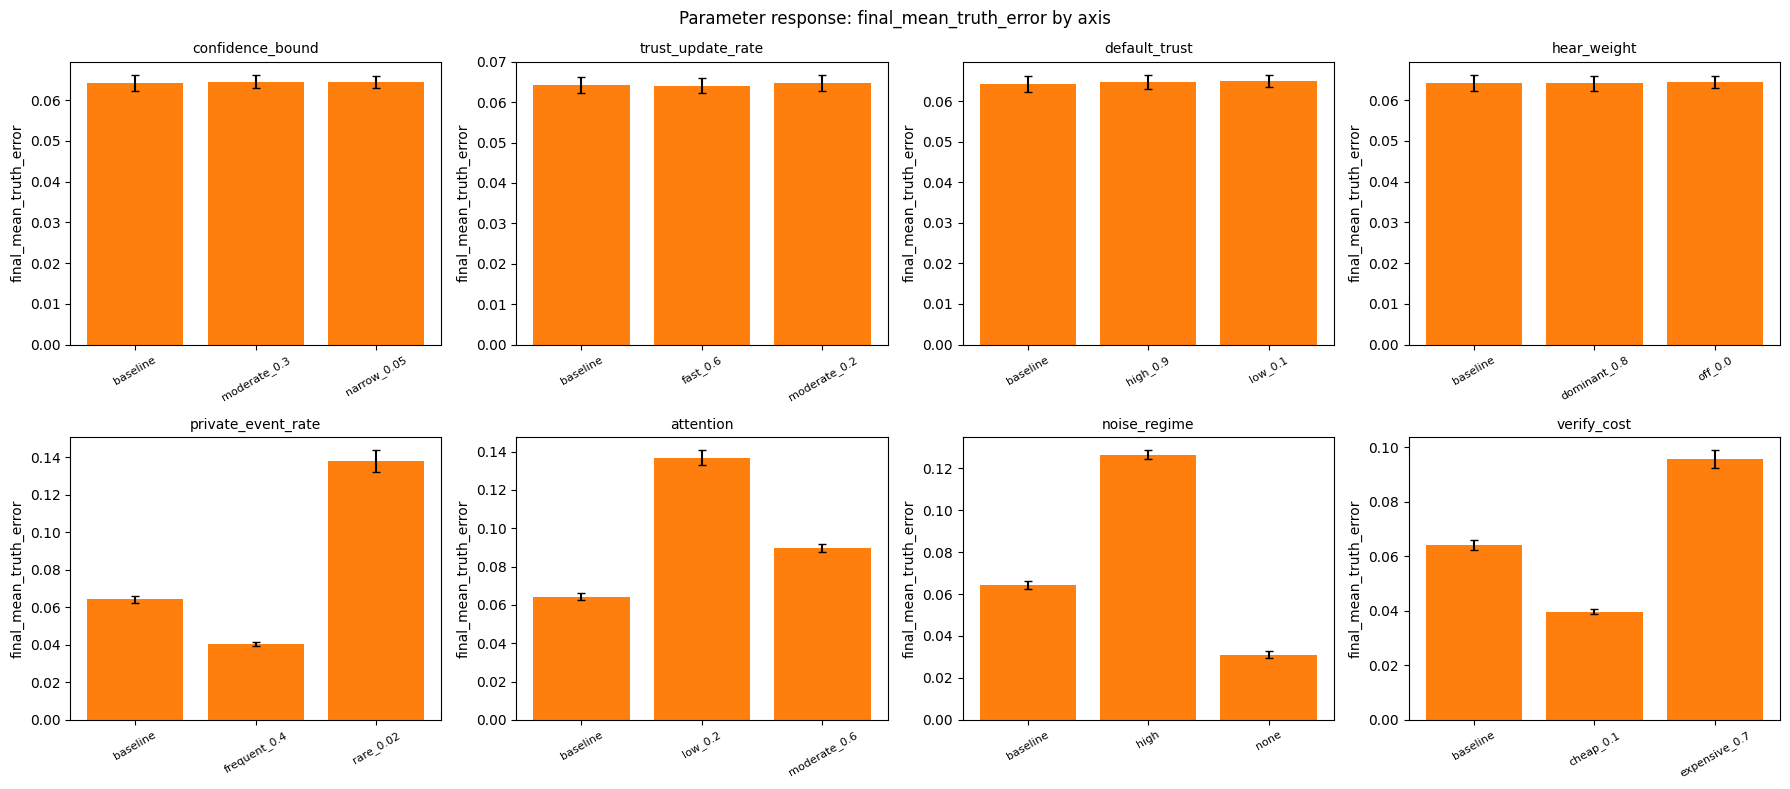

In [7]:
ofat = truth_anchored[truth_anchored.scenario_group.isin(["baseline", "ofat"])]
plot_parameter_response(ofat, "final_mean_truth_error")
plt.show()

**Reading this:** Channel-strength axes (`private_event_rate`, `attention`, `noise_regime`, `verify_cost`) move final truth error 4-5x (~0.03 to ~0.14). Social axes (`confidence_bound`, `trust_update_rate`, `default_trust`, `hear_weight`) move it by ~0.0005 against a seed std of ~0.002 -- within noise. See Mechanism activation for why that's not the same as "these mechanisms don't matter."

## Predictability with simple vs. nonlinear models

Linear/logistic regression vs. a random forest, used as landscape probes (not tuned for performance): does an additive model capture most of the predictable structure, or does a model that can represent interactions/thresholds do meaningfully better?

5-fold grouped CV R^2 (held-out scenarios)
                                    n   Linear  RandomForest
target                                                      
final_mean_truth_error            240  -34.394        -0.485
convergence_tick                  217   -3.568        -0.234
final_trust_std                   240    0.550         0.604
mean_belief_volatility            240   -0.135        -0.057
final_mean_claim_belief_variance  240 -269.836        -2.265

converged ~ swept params -- 5-fold grouped CV accuracy (majority baseline = 0.904)
  Logistic:     0.818
  RandomForest: 0.898


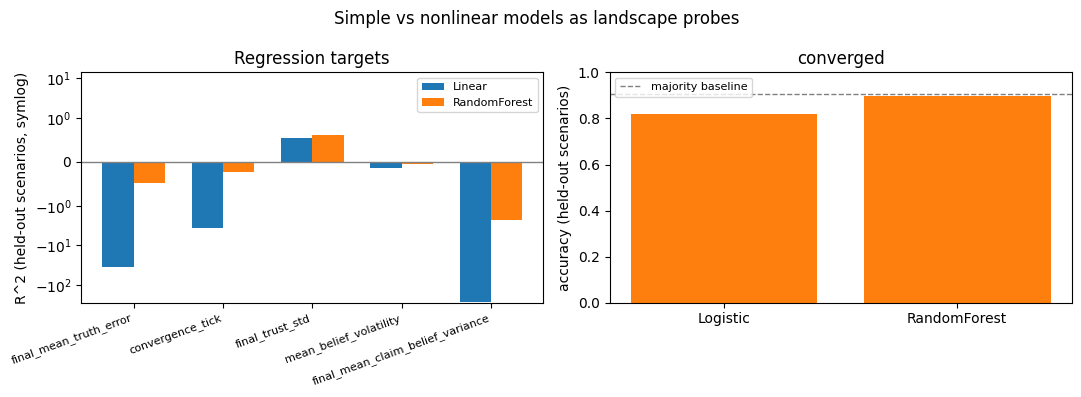

CPU times: user 2.7 s, sys: 8.96 ms, total: 2.71 s
Wall time: 2.04 s


In [8]:
%%time

# EDIT: feature columns relevant to the swept axes (see extract_scenario_features
# in simlab/run_analysis.py for the full set of available scenario-feature columns).
feature_cols = [
    "agent_confidence_bound_mean",
    "agent_trust_update_rate_mean",
    "agent_default_trust_mean",
    "agent_hear_weight_mean",
    "private_event_rate",
    "agent_attention_mean",
    "noise.OBSERVE",
    "noise.HEAR",
    "noise.VERIFY",
    "agent_action_cost.VERIFY_mean",
    "num_agents",
]
# EDIT: continuous outcome targets to probe -- compare each one's R^2 against
# its scenario-driven variance share above; low-share targets aren't expected
# to be very predictable from these features no matter the model.
regression_targets = [
    "final_mean_truth_error",
    "convergence_tick",
    "final_trust_std",
    "mean_belief_volatility",
    "final_mean_claim_belief_variance",
]
# EDIT: binary outcome target to probe (skipped automatically if it's constant
# -- most binary outcome labels here are close to constant, see Outcome diversity).
binary_target = "converged"

regression_df, classification = predictability_probe(
    truth_anchored, feature_cols, regression_targets, binary_target
)
print("5-fold grouped CV R^2 (held-out scenarios)")
print(regression_df.round(3).to_string())
if classification is not None:
    print(
        f"\n{binary_target} ~ swept params -- 5-fold grouped CV accuracy "
        f"(majority baseline = {classification['majority_baseline']:.3f})"
    )
    print(f"  Logistic:     {classification['Logistic']:.3f}")
    print(f"  RandomForest: {classification['RandomForest']:.3f}")

plot_predictability(regression_df, classification)
plt.show()

**Reading this:** Grouping CV folds by `scenario_fingerprint` matters here: every seed replicate of a scenario has an identical feature vector, so a row-level split would let a model score well just by recognizing a scenario it already saw in training -- memorization, not generalization. `final_trust_std` is the sanity check, not a finding: `Telemetry._trust_stats` pools every (agent, source) trust value across the whole population into one flattened std, so it can't distinguish an agent differentiating sharply across its own sources from different agents simply settling at different trust levels -- and since an untouched entry sits at the 0.5 default, the statistic is close to a direct restatement of `trust_update_rate` rather than emergent structure. That it's the one target that generalizes well (Linear R^2=0.55, RandomForest R^2=0.60) confirms the pipeline can detect real signal when a near-tautological relationship exists, not that it found something substantive about trust dynamics. Everything else fails to generalize, in varying degrees: `final_mean_truth_error` (-34.4, -0.49) and `final_mean_claim_belief_variance` (-269.8, -2.27) are the worst; `convergence_tick` (-3.57, -0.23, n=217 since it's undefined for non-converging runs) is milder and consistent with its real seed-driven variance share from the earlier decomposition (40%); `mean_belief_volatility` (-0.14, -0.06) is the most surprising -- despite being 92.5% scenario-driven there, it still doesn't generalize out-of-scenario, so "reproducible for a given scenario" and "predictable from these specific numeric features" are different claims. With only 24 unique configurations, almost all one OFAT step from baseline, there's too little scenario diversity for these targets to interpolate. For `converged`, logistic regression (81.8%) underperforms the majority-class baseline (90.4%), and the random forest (89.8%) barely matches it.

## Interaction: bounded confidence x dynamic trust

The one parameter pair with a clear a-priori interaction hypothesis, at a full 3x3 grid.

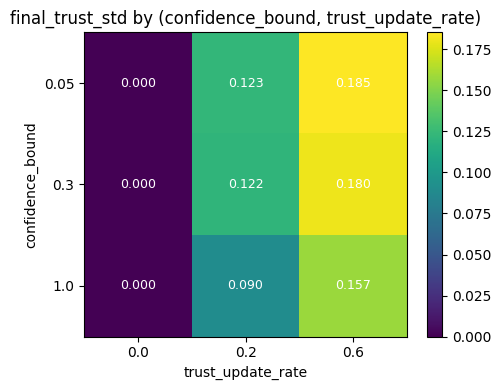

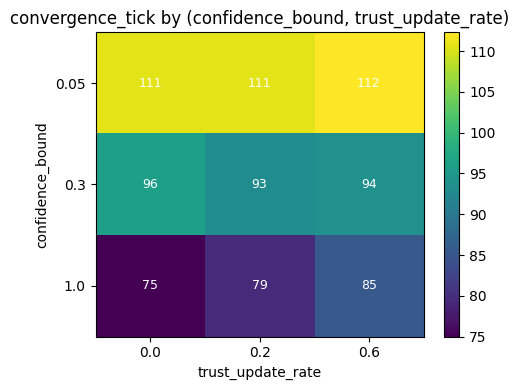

In [9]:
# Grid points that resolved to the same config as an earlier baseline/OFAT
# scenario were dropped by dedupe_scenarios above -- pull those in by the
# scenario_id they're identical to instead of expecting a row under the
# dropped id.
reused_ids = [
    kept_id
    for dropped_id, kept_id in INTERACTION_DUPLICATES.items()
    if dropped_id.startswith("interaction:")
]
interaction = truth_anchored[
    (truth_anchored.scenario_group == "interaction")
    | (truth_anchored.scenario_id.isin(reused_ids))
]


def interaction_heatmap(metric: str, title: str, fmt="{:.3f}"):
    pivot = interaction.pivot_table(
        index="agent_confidence_bound_mean",
        columns="agent_trust_update_rate_mean",
        values=metric,
        aggfunc="mean",
    )
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("trust_update_rate")
    ax.set_ylabel("confidence_bound")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(
                j,
                i,
                fmt.format(pivot.values[i, j]),
                ha="center",
                va="center",
                color="white",
                fontsize=9,
            )
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    return pivot


pivot_trust_std = interaction_heatmap(
    "final_trust_std", "final_trust_std by (confidence_bound, trust_update_rate)"
)
pivot_conv_tick = interaction_heatmap(
    "convergence_tick",
    "convergence_tick by (confidence_bound, trust_update_rate)",
    fmt="{:.0f}",
)

**Reading this:** `final_trust_std` is 0 whenever `trust_update_rate=0` (static by construction), then increases with it -- and, for a fixed rate, is consistently higher under a narrower confidence bound (0.185 at `cb=0.05` vs. 0.157 at `cb=1.0`, both at `trust_update_rate=0.6`): a narrow bound rejects more evidence, pushing realized trust values further from the default across the population -- though as noted above, this pooled statistic can't say whether that's individual agents differentiating sharply across sources or different agents simply settling at different trust levels. `convergence_tick` is consistently slower under a narrower bound (110.8 vs. 75.0 ticks at `trust_update_rate=0`); increasing `trust_update_rate` slightly slows convergence at wide bounds (75.0 -> 85.4) but barely at narrow ones (110.8 -> 112.3). These two mechanisms interact at the process level even though neither moves final truth error much.

## Mechanism activation

A mechanism being implemented doesn't mean it's doing anything in a typical run. Compare agent-tick activity fractions across a few scenarios, including `social_only`, where bounded confidence is the *only* thing shaping the outcome.

                              trust_update_frac  verify_frac  communicate_frac  broadcast_frac  observe_frac
scenario_id                                                                                                 
baseline                                 0.0000       0.0307            0.0155             0.0        0.1002
confidence_bound:narrow_0.05             0.0000       0.0283            0.0514             0.0        0.0997
trust_update_rate:fast_0.6               0.0147       0.0301            0.0172             0.0        0.1003
social_only:narrow_cb                    0.0000       0.0000            0.3067             0.0        0.0000


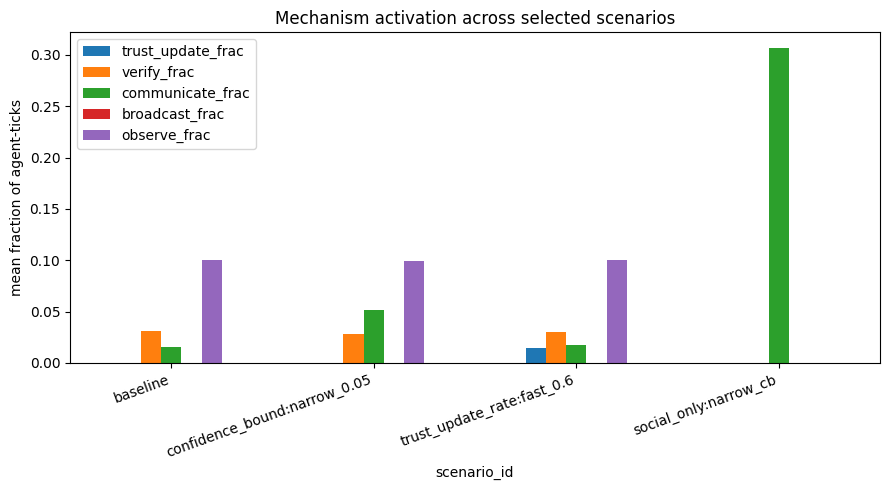

In [10]:
mech = runs.copy()
denom = mech["num_agents"] * STEPS
mech["trust_update_frac"] = mech["total_trust_updating_agent_ticks"] / denom
mech["verify_frac"] = mech["total_verifications"] / denom
mech["communicate_frac"] = mech["total_communicate_edges"] / denom
mech["broadcast_frac"] = mech["total_broadcast_edges"] / denom
mech["observe_frac"] = mech["total_observations"] / denom

mech_scenarios = [
    "baseline",
    "confidence_bound:narrow_0.05",
    "trust_update_rate:fast_0.6",
    "social_only:narrow_cb",
]
mech_summary = (
    mech[mech.scenario_id.isin(mech_scenarios)]
    .groupby("scenario_id")[
        [
            "trust_update_frac",
            "verify_frac",
            "communicate_frac",
            "broadcast_frac",
            "observe_frac",
        ]
    ]
    .mean()
    .reindex(mech_scenarios)
)
print(mech_summary.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
mech_summary.plot(kind="bar", ax=ax)
ax.set_ylabel("mean fraction of agent-ticks")
ax.set_title("Mechanism activation across selected scenarios")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Reading this:** `trust_update_frac` is 0 whenever `trust_update_rate=0` and nonzero when active -- inert unless turned on, as designed. `communicate_frac` roughly triples under a narrow confidence bound relative to baseline (0.051 vs. 0.016): rejecting more heard evidence keeps local disagreement higher, which the action-scoring heuristic rewards with more `COMMUNICATE` attempts -- bounded confidence is mechanically active even though it barely changes the final outcome. `social_only:narrow_cb` makes the reason legible: `verify_frac`/`observe_frac` are 0 by construction and `communicate_frac` is 0.307 (6-20x every other scenario shown), because `COMMUNICATE` is essentially the only thing agents ever do. Under that condition the population does *not* converge (truth error ~0.52-0.53, chance level), and final disagreement is markedly higher under a narrow bound (0.075) than a wide one (0.053) -- the textbook bounded-confidence fragmentation result, visible only once the truth-grounded channel is removed.

## Trajectory diversity

Final-state outcomes can hide very different paths. Compare five representative seed-0 trajectories: the fastest- and slowest-converging OFAT variants, a variant that never formally registers as "converged," and the social-only condition.

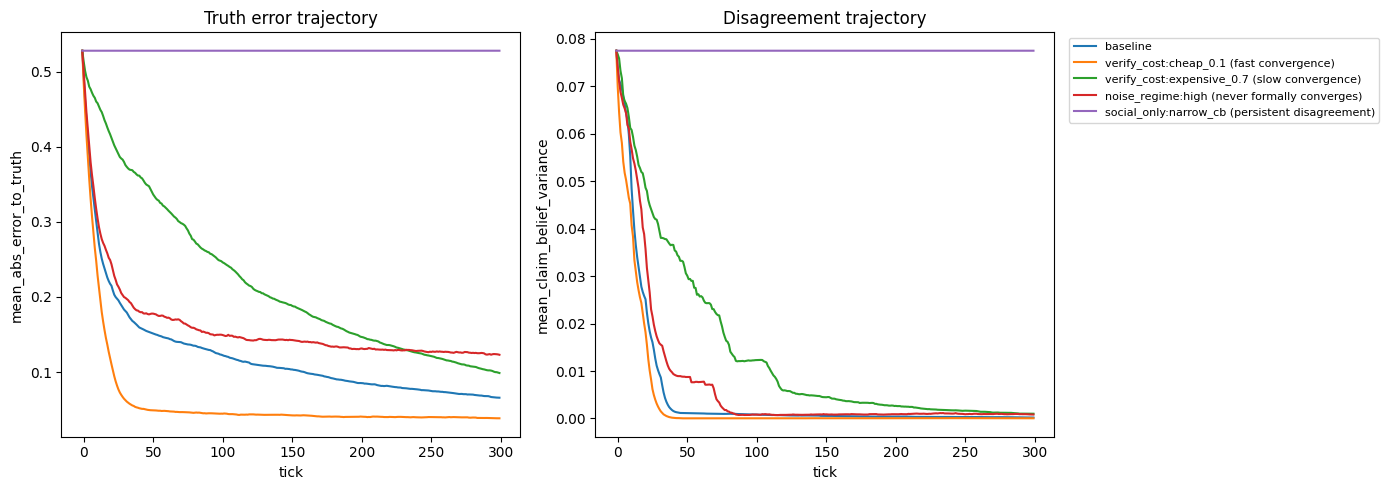

In [11]:
representative = {
    "baseline": "baseline",
    "verify_cost:cheap_0.1 (fast convergence)": "verify_cost:cheap_0.1",
    "verify_cost:expensive_0.7 (slow convergence)": "verify_cost:expensive_0.7",
    "noise_regime:high (never formally converges)": "noise_regime:high",
    "social_only:narrow_cb (persistent disagreement)": "social_only:narrow_cb",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for display_label, scenario_id in representative.items():
    rows = trajectories[scenario_id]
    ticks = [r.tick for r in rows]
    ax1.plot(ticks, [r.mean_abs_error_to_truth for r in rows], label=display_label)
    ax2.plot(ticks, [r.mean_claim_belief_variance for r in rows], label=display_label)
ax1.set_xlabel("tick")
ax1.set_ylabel("mean_abs_error_to_truth")
ax1.set_title("Truth error trajectory")
ax2.set_xlabel("tick")
ax2.set_ylabel("mean_claim_belief_variance")
ax2.set_title("Disagreement trajectory")
ax2.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
plt.tight_layout()
plt.show()

**Reading this:** `verify_cost:cheap` drops truth error almost immediately and flattens by ~tick 50; `verify_cost:expensive` declines steadily but hasn't fully flattened by tick 300 (~0.10, ~2.5x cheap's) -- a genuinely different trajectory shape, not a shifted copy. `noise_regime:high` plateaus around ~0.13 with visible residual jitter -- stable-but-noisy rather than quiet, exactly why `find_convergence_tick` never triggers for it. `social_only:narrow_cb` is flat from tick 0: with a 0.05-wide bound between independently-random initial beliefs, very few `HEAR` messages land inside the bound, so belief barely drifts over 300 ticks -- effectively frozen near its initial disagreement.

## Conclusions

**Behavioral outcomes.** One dominant regime when any truth-grounded channel exists: 100% truth-aligned, 0% false consensus, 99.2% consensus across 240 runs. Convergence speed spans ~42-218 ticks, driven by channel-strength parameters. Persistent disagreement only appears once the channel is removed entirely (`social_only`).

**Variability.** Scenario variance dominates seed variance for the metrics that matter most (truth error 99.3%, volatility 92.5%); `convergence_tick` has a real seed component (60.0%), consistent with a threshold-crossing event.

**Mechanisms.** Channel-strength parameters materially move final truth error (4-5x range). Bounded confidence and dynamic trust change process-level behavior (communicate volume triples under a narrow bound; trust dispersion scales with `trust_update_rate`) but barely move the outcome while any truth-grounded channel exists -- and become outcome-relevant once it's removed (`social_only`: narrower bound -> higher persistent disagreement, 0.075 vs. 0.053).

**Complexity.** Whether a model generalizes to held-out configurations depends entirely on the target (see Predictability): `final_trust_std`, mechanically tied to `trust_update_rate`, generalizes well (R^2 up to 0.60) -- confirming the grouped-CV pipeline itself works. `final_mean_truth_error` and `final_mean_claim_belief_variance` don't generalize at all (R^2 strongly negative), a design-size limitation (only 24 unique truth-anchored configurations, mostly one OFAT step from baseline) rather than evidence the kernel's response surface is smooth. `mean_belief_volatility` is the subtler case: 92.5% scenario-driven yet still not predictable out-of-scenario, showing "reproducible per scenario" and "predictable from these features" aren't the same claim. Trajectories reaching similar final states can still take visibly different shapes and speeds (cheap vs. expensive verification), and a stable-but-noisy regime (`noise_regime:high`) is mechanically distinct from a quiet one.

**Next direction.** The truth-anchored operating region is behaviorally narrow, but that looks channel-driven, not kernel-wide -- `social_only` shows the kernel can produce a qualitatively different regime once the dominant channel is removed. Investigate that boundary (weaker channels, multiple/conflicting claims, partial-channel populations) before concluding the kernel needs new mechanisms.

## Follow-up work

Evidence-driven candidates for separate PRs, not implemented here.

**Telemetry PRs**
- Record `HEAR` accept/reject counts directly (inferred here indirectly via `communicate_frac`).
- Record trust-update magnitude, not just whether it changed (`final_trust_std` was a proxy).
- Decompose the flattened `trust_std` into within-agent (spread across one agent's own sources) and between-agent (spread of agents' overall trust levels) components -- the current pooled statistic conflates these, which is why it tracks `trust_update_rate` almost tautologically instead of revealing real trust structure (see the predictability and interaction readings above).

**Run-analysis PRs**
- Refine `find_convergence_tick`: `private_event_rate:frequent_0.4` and `noise_regime:high` never register as converged despite stable, truth-aligned consensus, because persistent low-amplitude activity keeps `mean_abs_delta` above threshold.
- Current labels conflate "settled" with "quiet."

**Kernel PRs**
- This sweep tested one always-true claim. Multiple/conflicting claims, or a population where only some agents have a truth-grounded channel, are natural next probes.

**Experiment-infrastructure PRs**
- A broader random/Latin-hypercube design (more, and more varied, unique configurations) is needed to say more about targets like `final_mean_truth_error` and `mean_belief_volatility`, where 24 configurations wasn't enough for either model to beat a mean baseline under grouped CV -- `final_trust_std` shows the pipeline itself can detect real signal when a near-tautological relationship exists.

**Whenever this notebook is committed:** add a row to `notebooks/README.md` (date, file, kernel commit, one-line finding).